# Step 2 — Prepare the Data (Parte 1)
## Etapa 2.2 — Análise Exploratória de Dados (EDA)

**Projeto:** Tech Challenge Fase 1 — Desafio B — Detecção de Pneumonia  
**Metodologia:** ML Life Cycle — Step 2: Prepare the Data (EDA)  

---

### Objetivo

Esta etapa tem como objetivo **conhecer os dados antes de modelar**. A EDA responde perguntas críticas:

- As classes estão balanceadas?
- Existem valores nulos?
- As features numéricas apresentam distribuições normais ou assimétricas?
- Alguma feature diferencia bem as 3 classes (pneumonia, edema pulmonar, atelectasia)?
- Existem correlações entre as features que possam indicar multicolinearidade?

As conclusões desta etapa guiarão as decisões de pré-processamento (Etapa 2.3).

---

## 1. Importações

In [1]:
# Dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print('Bibliotecas carregadas com sucesso.')
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'seaborn : {sns.__version__}')

Bibliotecas carregadas com sucesso.
pandas  : 3.0.3
numpy   : 2.4.4
seaborn : 0.13.2


---

## 2. Constantes

In [2]:
RANDOM_STATE = 42
DATA_PATH    = '../data/tabular/'
REPORTS_PATH = '../reports/'
TARGET       = 'true_label'

# Features definidas na etapa 2.1 (01_coleta_dados.ipynb)
FEATURES_BINARIAS   = ['fever', 'tachycardia', 'crackles']
FEATURES_NUMERICAS  = ['oxygen_saturation', 'wbc_count']
FEATURE_CATEGORICA  = 'chest_xray_result'
COLUNAS_DESCARTAR   = ['patient_id', 'timestamp', 'note_sequence', 'clinical_note', 'uncertainty_score']

# Paleta de cores para as 3 classes
PALETTE_CLASSES = {
    'pneumonia'      : '#E74C3C',
    'pulmonary edema': '#3498DB',
    'atelectasis'    : '#2ECC71',
}

print('Constantes definidas.')

Constantes definidas.


---

## 3. Carregamento do Dataset

In [3]:
df = pd.read_csv(f'{DATA_PATH}clinical_pneumonia_dataset.csv')

print(f'Dataset carregado com sucesso!')
print(f'  Shape     : {df.shape}')
print(f'  Pacientes : {df["patient_id"].nunique():,} únicos')
print()
df.head(3)

Dataset carregado com sucesso!
  Shape     : (1500, 12)
  Pacientes : 297 únicos



,patient_id,timestamp,note_sequence,clinical_note,fever,tachycardia,crackles,oxygen_saturation,wbc_count,chest_xray_result,true_label,uncertainty_score
0,PNE-6733,2022-06-11,0,Pyrexia. rapid heart rate. rales. hypoxemia. p...,1,1,1,93.5,7.5,consolidation,pneumonia,0.77
1,PNE-6733,2022-06-12,1,Fever. tachycardia. rales. spo2 < 94%. product...,1,1,1,93.5,7.5,consolidation,pneumonia,0.85
2,PNE-6733,2022-06-13,2,Raised body temp. tachycardia. crackles. spo2 ...,1,1,1,93.5,7.5,consolidation,pneumonia,0.96


---

## 4. Visão Geral dos Dados

In [5]:
print('=== TIPOS E NULOS POR COLUNA ===')
print()
df.info()

=== TIPOS E NULOS POR COLUNA ===

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         1500 non-null   str    
 1   timestamp          1500 non-null   str    
 2   note_sequence      1500 non-null   int64  
 3   clinical_note      1500 non-null   str    
 4   fever              1500 non-null   int64  
 5   tachycardia        1500 non-null   int64  
 6   crackles           1500 non-null   int64  
 7   oxygen_saturation  1500 non-null   float64
 8   wbc_count          1500 non-null   float64
 9   chest_xray_result  1500 non-null   str    
 10  true_label         1500 non-null   str    
 11  uncertainty_score  1500 non-null   float64
dtypes: float64(3), int64(4), str(5)
memory usage: 140.8 KB


In [6]:
print('=== ESTATÍSTICAS DESCRITIVAS (features numéricas) ===')
display(df[FEATURES_NUMERICAS + ['uncertainty_score']].describe().round(3))

=== ESTATÍSTICAS DESCRITIVAS (features numéricas) ===


,oxygen_saturation,wbc_count,uncertainty_score
count,1500.000,1500.000,1500.000
mean,94.592,8.460,0.661
std,1.860,1.271,0.192
min,90.520,6.000,0.300
25%,93.094,7.400,0.490
50%,94.644,8.500,0.700
75%,96.200,9.500,0.810
max,98.000,10.861,0.990


**Leitura das estatísticas:**

| Feature | Mín | Média | Máx | Interpretação clínica |
|---|---|---|---|---|
| `oxygen_saturation` | 90,5% | 94,6% | 98,0% | Valores <94% indicam hipoxemia — sinal de alerta |
| `wbc_count` | 6,0 K/µL | 8,5 K/µL | 10,9 K/µL | Referência normal: 4,5–11 K/µL — todos dentro do range |

> O desvio padrão da saturação de oxigênio (±1,86) indica variação clinicamente relevante dentro do dataset.

---

## 5. Análise de Valores Nulos

In [7]:
nulos = pd.DataFrame({
    'Nulos'     : df.isnull().sum(),
    'Percentual': (df.isnull().sum() / len(df) * 100).round(2),
})

print('=== ANÁLISE DE VALORES NULOS ===')
display(nulos)
print(f'\nTotal de células nulas: {df.isnull().sum().sum()}')

=== ANÁLISE DE VALORES NULOS ===


,Nulos,Percentual
patient_id,0,0.0
timestamp,0,0.0
note_sequence,0,0.0
clinical_note,0,0.0
fever,0,0.0
tachycardia,0,0.0
crackles,0,0.0
oxygen_saturation,0,0.0
wbc_count,0,0.0
chest_xray_result,0,0.0



Total de células nulas: 0


**Resultado:** O dataset não possui nenhum valor nulo em nenhuma coluna (0 de 1.500 registros).

**Impacto no pré-processamento:** Não será necessária nenhuma estratégia de imputação (mediana, moda ou modelos preditivos). A etapa 2.3 poderá focar diretamente em encoding e normalização.

---

## 6. Distribuição da Variável Target

=== DISTRIBUIÇÃO DO TARGET ===


,Contagem,Percentual (%)
true_label,,
pneumonia,500,33.33
pulmonary edema,500,33.33
atelectasis,500,33.33


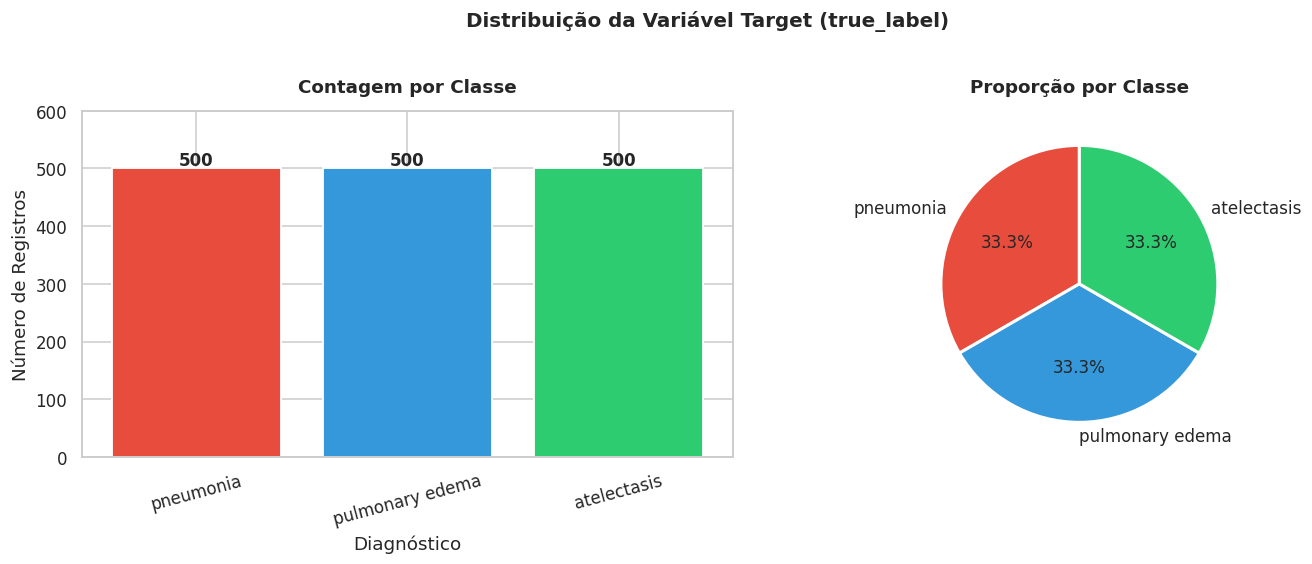

Gráfico salvo em reports/eda_target_distribuicao.png


In [7]:
contagem_target = df[TARGET].value_counts()
pct_target      = (contagem_target / len(df) * 100).round(2)

print('=== DISTRIBUIÇÃO DO TARGET ===')
display(pd.DataFrame({'Contagem': contagem_target, 'Percentual (%)': pct_target}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico de barras
cores = [PALETTE_CLASSES[c] for c in contagem_target.index]
axes[0].bar(contagem_target.index, contagem_target.values, color=cores, edgecolor='white', linewidth=1.2)
axes[0].set_title('Contagem por Classe', fontweight='bold', pad=12)
axes[0].set_ylabel('Número de Registros')
axes[0].set_xlabel('Diagnóstico')
for i, (label, v) in enumerate(zip(contagem_target.index, contagem_target.values)):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 600)
axes[0].tick_params(axis='x', rotation=15)

# Pizza
axes[1].pie(
    contagem_target.values,
    labels=contagem_target.index,
    autopct='%1.1f%%',
    colors=cores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporção por Classe', fontweight='bold', pad=12)

plt.suptitle('Distribuição da Variável Target (true_label)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{REPORTS_PATH}eda_target_distribuicao.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico salvo em reports/eda_target_distribuicao.png')

**Resultado:** O dataset está **perfeitamente balanceado** — exatamente 500 registros (33,33%) para cada uma das 3 classes: `pneumonia`, `pulmonary edema` e `atelectasis`.

**Impacto no projeto:**
- **Não é necessário** oversampling (SMOTE) nem undersampling
- **Não é necessário** `class_weight='balanced'` nos modelos (embora não prejudique testar)
- A **Accuracy** pode ser usada como métrica complementar, mas o **Recall por classe** continua sendo a métrica principal — errar em qualquer uma das 3 condições tem impacto clínico
- Baseline teórico de um classificador aleatório: ~33,3% — modelos devem superar significativamente este valor

> **Nota:** Em dados clínicos reais, pneumonia tende a ser a condição mais frequente. O balanceamento perfeito aqui é característica do dataset sintético.

---

## 7. Features Binárias: Distribuição Global e por Classe

In [8]:
print('=== FEATURES BINÁRIAS — DISTRIBUIÇÃO GLOBAL ===')
for col in FEATURES_BINARIAS:
    contagem = df[col].value_counts()
    print(f'\n{col}:')
    for val, cnt in contagem.items():
        label_txt = 'Presente' if val == 1 else 'Ausente'
        print(f'  {val} ({label_txt}) → {cnt:>4} registros ({cnt/len(df)*100:.1f}%)')

=== FEATURES BINÁRIAS — DISTRIBUIÇÃO GLOBAL ===

fever:
  1 (Presente) → 1136 registros (75.7%)
  0 (Ausente) →  364 registros (24.3%)

tachycardia:
  1 (Presente) →  915 registros (61.0%)
  0 (Ausente) →  585 registros (39.0%)

crackles:
  1 (Presente) →  811 registros (54.1%)
  0 (Ausente) →  689 registros (45.9%)


=== PROPORÇÃO DE PRESENÇA (valor=1) POR CLASSE ===


,fever,tachycardia,crackles
true_label,,,
atelectasis,0.762,0.67,0.410
pneumonia,0.756,0.58,0.742
pulmonary edema,0.754,0.58,0.470


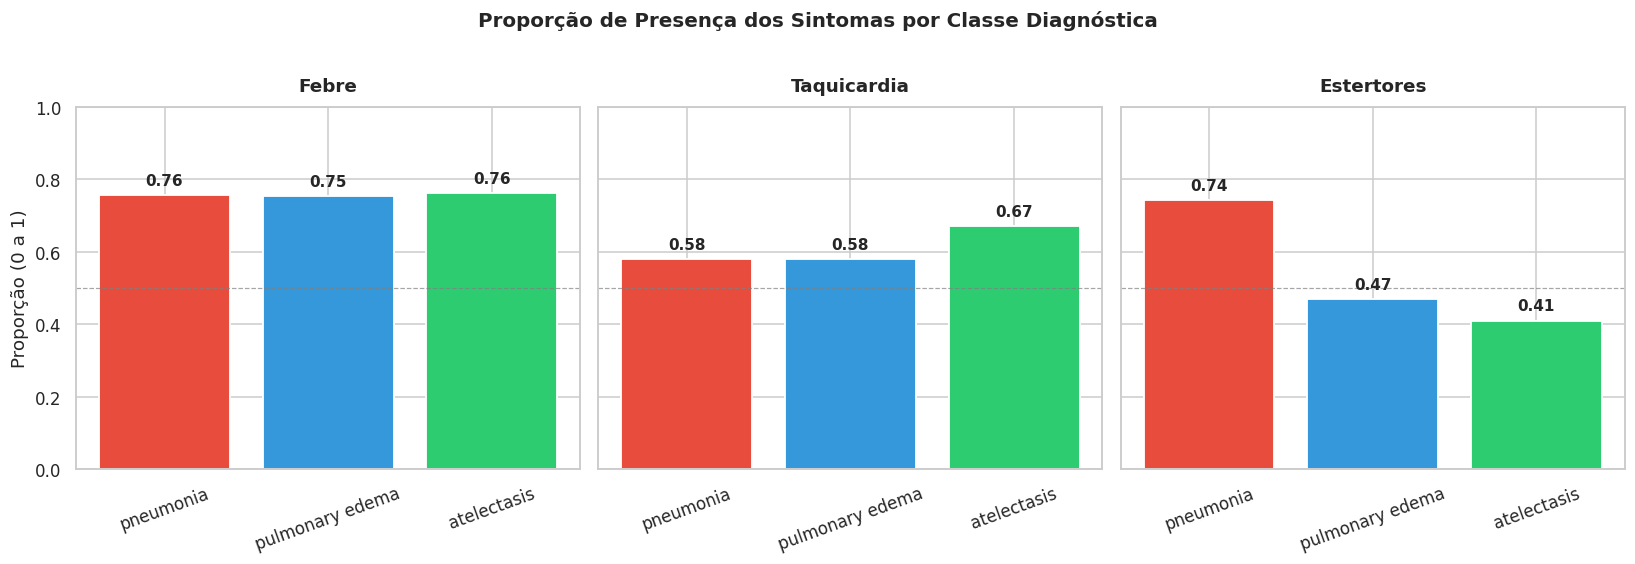

Gráfico salvo em reports/eda_features_binarias.png


In [9]:
# Proporção de presença (valor=1) por classe
prop_por_classe = df.groupby(TARGET)[FEATURES_BINARIAS].mean().round(3)

print('=== PROPORÇÃO DE PRESENÇA (valor=1) POR CLASSE ===')
display(prop_por_classe)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

labels_rotulo = {'fever': 'Febre', 'tachycardia': 'Taquicardia', 'crackles': 'Estertores'}

for ax, col in zip(axes, FEATURES_BINARIAS):
    classes_ord = list(PALETTE_CLASSES.keys())
    valores     = [prop_por_classe.loc[c, col] for c in classes_ord]
    cores       = [PALETTE_CLASSES[c] for c in classes_ord]

    bars = ax.bar(classes_ord, valores, color=cores, edgecolor='white', linewidth=1.2)
    ax.set_title(labels_rotulo[col], fontweight='bold', pad=10)
    ax.set_ylabel('Proporção (0 a 1)' if ax == axes[0] else '')
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Proporção de Presença dos Sintomas por Classe Diagnóstica',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{REPORTS_PATH}eda_features_binarias.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico salvo em reports/eda_features_binarias.png')

**Leitura dos gráficos — sintomas por classe:**

| Feature | Pneumonia | Edema Pulmonar | Atelectasia | Diferenciação |
|---|---|---|---|---|
| Febre | 76% | 75% | 76% | **Baixa** — praticamente igual nas 3 classes |
| Taquicardia | 58% | 58% | 67% | **Moderada** — atelectasia apresenta mais taquicardia |
| **Estertores** | **74%** | 47% | 41% | **Alta** — forte marcador de pneumonia |

**Insight principal:** `crackles` (estertores) é o **único sintoma binário com poder discriminativo real**. Estertores presentes em ~74% dos casos de pneumonia contra ~47% no edema e ~41% na atelectasia. Esse padrão é clinicamente consistente: os estertores (sons crepitantes à ausculta) são classicamente associados a pneumonia bacteriana.

**Febre** não diferencia as classes — aparece com frequência similar nas 3 condições, refletindo que todas podem cursar com resposta inflamatória.

---

## 8. Features Numéricas: Distribuições

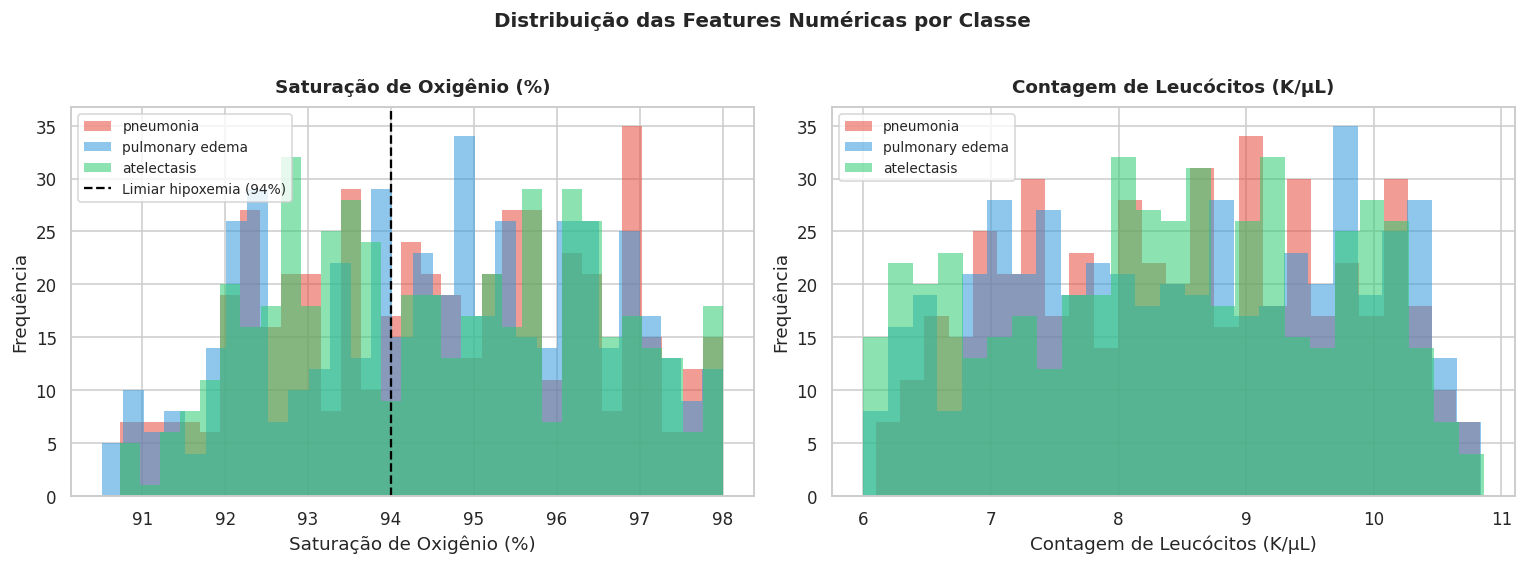

Gráfico salvo em reports/eda_distribuicoes_numericas.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs = {
    'oxygen_saturation': {'titulo': 'Saturação de Oxigênio (%)', 'bins': 30, 'linha_ref': 94, 'label_ref': 'Limiar hipoxemia (94%)'},
    'wbc_count'        : {'titulo': 'Contagem de Leucócitos (K/µL)', 'bins': 25, 'linha_ref': None, 'label_ref': None},
}

for ax, col in zip(axes, FEATURES_NUMERICAS):
    cfg = configs[col]

    for classe, cor in PALETTE_CLASSES.items():
        dados = df[df[TARGET] == classe][col]
        ax.hist(dados, bins=cfg['bins'], alpha=0.55, label=classe, color=cor, edgecolor='none')

    if cfg['linha_ref']:
        ax.axvline(cfg['linha_ref'], color='black', linestyle='--', linewidth=1.5,
                   label=cfg['label_ref'])

    ax.set_title(cfg['titulo'], fontweight='bold', pad=10)
    ax.set_xlabel(cfg['titulo'])
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=9)

plt.suptitle('Distribuição das Features Numéricas por Classe', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{REPORTS_PATH}eda_distribuicoes_numericas.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico salvo em reports/eda_distribuicoes_numericas.png')

**Leitura dos histogramas:**

- **Saturação de O₂:** As distribuições das 3 classes se sobrepõem quase completamente, indicando **baixo poder discriminativo** desta feature isoladamente. A linha de referência clínica (94%) mostra que parte dos registros está na faixa de hipoxemia — esperado num dataset de condições respiratórias.

- **Leucócitos (WBC):** Similarmente, as 3 classes apresentam distribuições muito próximas (~8,5 K/µL de média). Na prática clínica, leucocitose (>11 K/µL) seria esperada principalmente em pneumonia bacteriana, mas esse dataset sintético não reproduz essa diferença.

**Conclusão:** As features numéricas, por si só, têm **limitado poder preditivo** neste dataset. O modelo precisará combinar múltiplas features — especialmente `crackles` e `chest_xray_result` — para distinguir as classes.

---

## 9. Boxplots: Features Numéricas por Classe

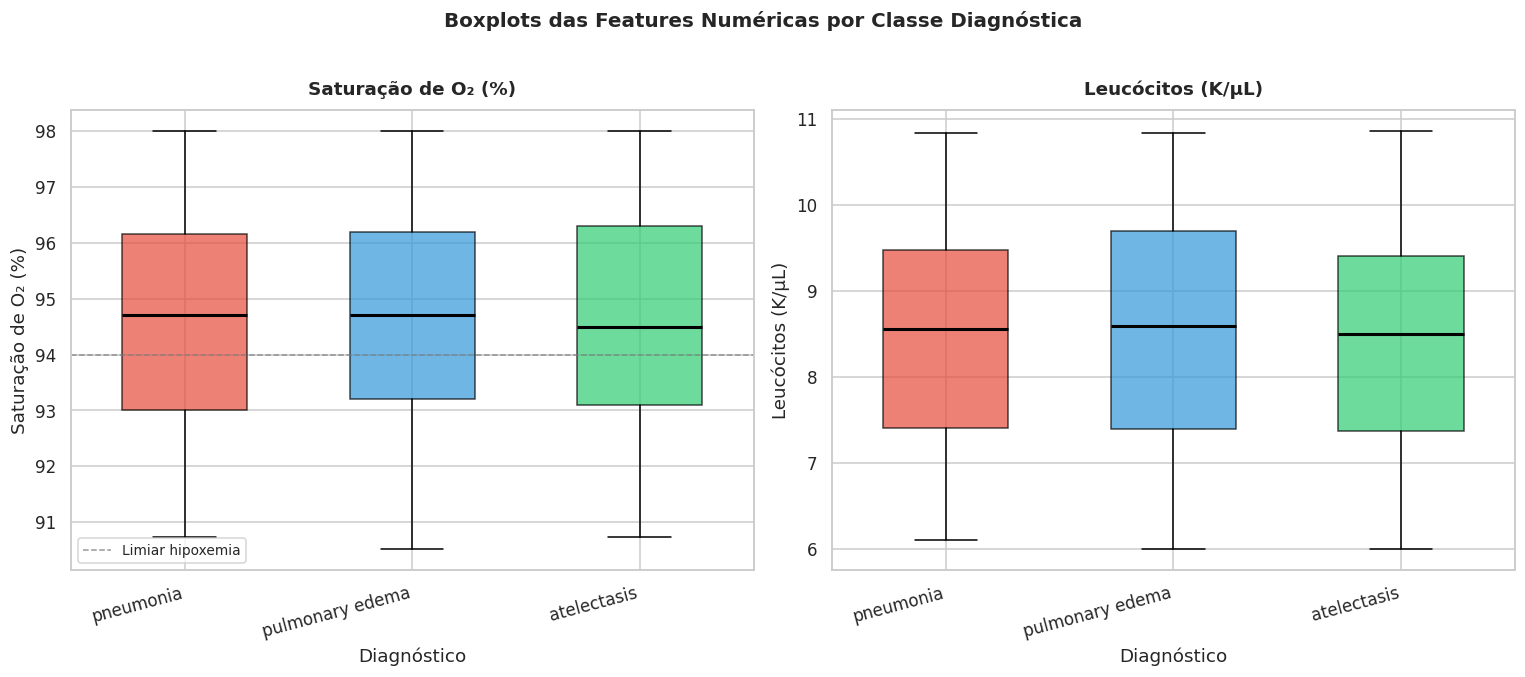

Gráfico salvo em reports/eda_boxplots_por_classe.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rotulos = {
    'oxygen_saturation': 'Saturação de O₂ (%)',
    'wbc_count'        : 'Leucócitos (K/µL)',
}

for ax, col in zip(axes, FEATURES_NUMERICAS):
    ordem_classes = list(PALETTE_CLASSES.keys())
    cores_lista   = list(PALETTE_CLASSES.values())

    bp = ax.boxplot(
        [df[df[TARGET] == c][col].values for c in ordem_classes],
        patch_artist=True,
        notch=False,
        widths=0.55,
    )
    for patch, cor in zip(bp['boxes'], cores_lista):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
    for median in bp['medians']:
        median.set(color='black', linewidth=2)

    ax.set_xticklabels(ordem_classes, rotation=15, ha='right')
    ax.set_title(rotulos[col], fontweight='bold', pad=10)
    ax.set_ylabel(rotulos[col])
    ax.set_xlabel('Diagnóstico')

    # Linha de referência clínica
    if col == 'oxygen_saturation':
        ax.axhline(94, color='gray', linestyle='--', linewidth=1, alpha=0.8, label='Limiar hipoxemia')
        ax.legend(fontsize=9)

plt.suptitle('Boxplots das Features Numéricas por Classe Diagnóstica',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{REPORTS_PATH}eda_boxplots_por_classe.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico salvo em reports/eda_boxplots_por_classe.png')

**Leitura dos boxplots:**

| Feature | Pneumonia | Edema Pulmonar | Atelectasia | Conclusão |
|---|---|---|---|---|
| Saturação O₂ | Med ~94,6% | Med ~94,6% | Med ~94,6% | **Idêntica** — não discrimina |
| Leucócitos | Med ~8,5 K/µL | Med ~8,5 K/µL | Med ~8,5 K/µL | **Idêntica** — não discrimina |

Os boxplots confirmam visualmente o que as médias já indicavam: **as features numéricas têm medianas e dispersões praticamente idênticas nas 3 classes**. Outliers existem em ambas as features, mas são simétricos entre classes.

> **Implicação para o modelo:** Features numéricas provavelmente contribuirão pouco como preditores individualmente. O modelo dependerá principalmente das features binárias (especialmente `crackles`) e da feature categórica (`chest_xray_result`) para fazer distinções. SHAP na etapa 2.7 confirmará esse raciocínio.

---

## 10. Feature Categórica: Resultado do Raio-X por Classe

=== CHEST X-RAY RESULT × TRUE_LABEL (proporção por achado) ===


true_label,atelectasis,pneumonia,pulmonary edema
chest_xray_result,,,
consolidation,0.337,0.343,0.321
effusion,0.369,0.325,0.307
infiltrate,0.312,0.346,0.343
normal,0.323,0.335,0.342
opacity,0.332,0.314,0.354


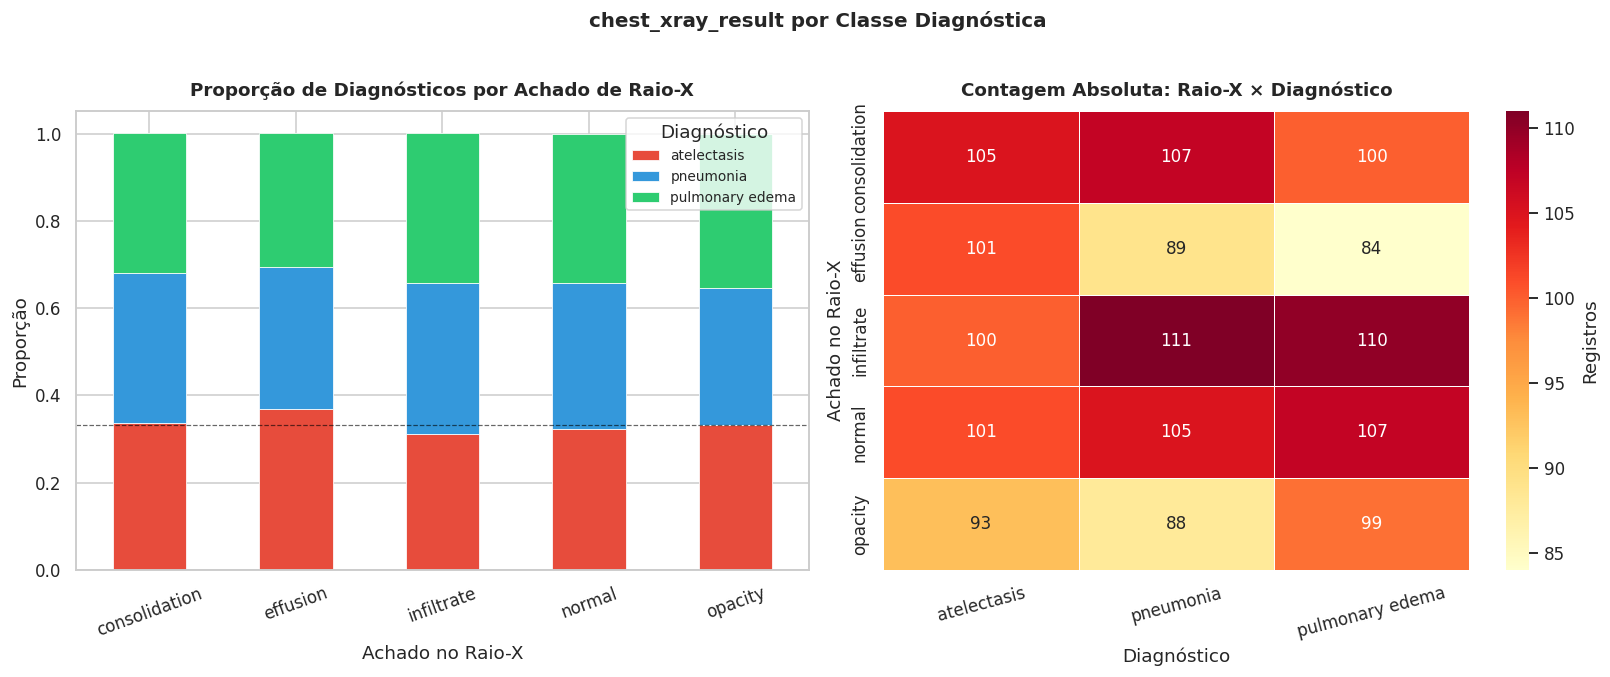

Gráfico salvo em reports/eda_raio_x_por_classe.png


In [12]:
# Tabela de contingência: raio-X × diagnóstico
ct = pd.crosstab(df[FEATURE_CATEGORICA], df[TARGET], normalize='index').round(3)

print('=== CHEST X-RAY RESULT × TRUE_LABEL (proporção por achado) ===')
display(ct)

ct_abs = pd.crosstab(df[FEATURE_CATEGORICA], df[TARGET])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras empilhadas (proporção)
ct.plot(kind='bar', stacked=True, ax=axes[0],
        color=list(PALETTE_CLASSES.values()), edgecolor='white', linewidth=0.5)
axes[0].set_title('Proporção de Diagnósticos por Achado de Raio-X', fontweight='bold', pad=10)
axes[0].set_ylabel('Proporção')
axes[0].set_xlabel('Achado no Raio-X')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Diagnóstico', loc='upper right', fontsize=9)
axes[0].axhline(0.333, color='black', linestyle='--', linewidth=0.8, alpha=0.6, label='Baseline 33,3%')

# Heatmap de contagens absolutas
sns.heatmap(ct_abs, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Registros'})
axes[1].set_title('Contagem Absoluta: Raio-X × Diagnóstico', fontweight='bold', pad=10)
axes[1].set_xlabel('Diagnóstico')
axes[1].set_ylabel('Achado no Raio-X')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('chest_xray_result por Classe Diagnóstica', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{REPORTS_PATH}eda_raio_x_por_classe.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico salvo em reports/eda_raio_x_por_classe.png')

**Leitura dos gráficos — raio-X por classe:**

| Achado Radiológico | Pneumonia | Edema Pulmonar | Atelectasia | Padrão clínico esperado |
|---|---|---|---|---|
| Consolidation | ~34% | ~32% | ~34% | Pneumonia → mas distribuído uniformemente aqui |
| Infiltrate | ~35% | ~34% | ~31% | Pneumonia/Edema → sem diferenciação no dataset |
| Normal | ~34% | ~34% | ~32% | Esperado em atelectasia leve → sem diferenciação |
| Opacity | ~31% | ~35% | ~33% | Edema → levemente mais frequente, mas sem significância |
| Effusion | ~32% | ~30% | ~37% | Atelectasia/Edema → invertido clinicamente |

**Conclusão crítica:** `chest_xray_result` **não apresenta poder discriminativo** neste dataset. As proporções de cada achado são praticamente uniformes (~33%) entre os 3 diagnósticos. Isso é uma característica do dataset sintético — na prática clínica real, consolidação seria fortemente associada a pneumonia, e derrame pleural ao edema pulmonar.

> **Implicação para o modelo:** A feature categórica precisará de encoding (One-Hot ou Ordinal), mas sua contribuição preditiva será limitada. O modelo provavelmente aprenderá a dar pouco peso a ela — algo que o SHAP confirmará na etapa 2.7.

---

## 11. Análise de Correlação

=== MATRIZ DE CORRELAÇÃO ===


,Febre,Taquicardia,Estertores,Saturação O₂,Leucócitos,Raio-X (enc),Diagnóstico (enc)
Febre,1.000,-0.029,0.018,-0.001,0.039,0.017,0.006
Taquicardia,-0.029,1.000,0.006,0.041,-0.024,-0.024,0.075
Estertores,0.018,0.006,1.000,-0.046,0.099,0.015,-0.272
Saturação O₂,-0.001,0.041,-0.046,1.000,-0.032,-0.007,-0.008
Leucócitos,0.039,-0.024,0.099,-0.032,1.000,-0.006,-0.032
Raio-X (enc),0.017,-0.024,0.015,-0.007,-0.006,1.000,-0.001
Diagnóstico (enc),0.006,0.075,-0.272,-0.008,-0.032,-0.001,1.000


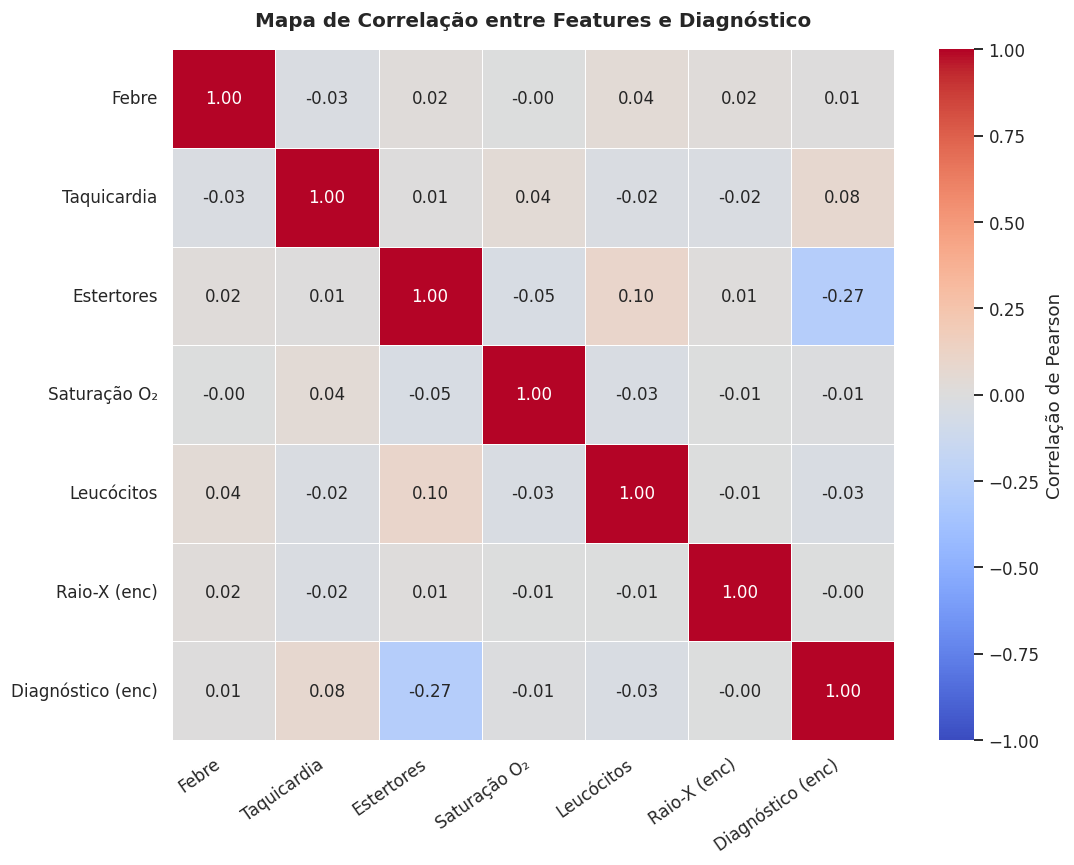

Gráfico salvo em reports/eda_correlacao.png


In [13]:
# Encoding numérico do target e da feature categórica para incluir na correlação
df_corr = df[FEATURES_BINARIAS + FEATURES_NUMERICAS].copy()
df_corr['chest_xray_enc'] = df[FEATURE_CATEGORICA].astype('category').cat.codes
df_corr['diagnostico_enc'] = df[TARGET].map({'pneumonia': 0, 'pulmonary edema': 1, 'atelectasis': 2})

corr_matrix = df_corr.corr()

# Renomear para melhor legibilidade
nomes_legivel = {
    'fever'            : 'Febre',
    'tachycardia'      : 'Taquicardia',
    'crackles'         : 'Estertores',
    'oxygen_saturation': 'Saturação O₂',
    'wbc_count'        : 'Leucócitos',
    'chest_xray_enc'   : 'Raio-X (enc)',
    'diagnostico_enc'  : 'Diagnóstico (enc)',
}
corr_matrix.rename(index=nomes_legivel, columns=nomes_legivel, inplace=True)

print('=== MATRIZ DE CORRELAÇÃO ===')
display(corr_matrix.round(3))

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Correlação de Pearson'},
    annot_kws={'size': 11}
)
plt.title('Mapa de Correlação entre Features e Diagnóstico', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{REPORTS_PATH}eda_correlacao.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico salvo em reports/eda_correlacao.png')

**Leitura do heatmap de correlação:**

| Par de variáveis | Correlação | Interpretação |
|---|---|---|
| Estertores ↔ Diagnóstico | **-0.27** | Correlação negativa moderada — crackles=1 associado a classe 0 (pneumonia) |
| Taquicardia ↔ Diagnóstico | +0.08 | Fraca — leve associação com classes 1/2 (edema/atelectasia) |
| Todas as demais | < ±0.10 | **Muito fracas** — praticamente sem correlação linear |

**Observações críticas:**

1. **Ausência de multicolinearidade:** Nenhum par de features apresenta correlação >|0.30|, o que é positivo — não será necessário remover features redundantes.

2. **`crackles` é o preditor mais correlacionado** com o diagnóstico (-0.27). O sinal negativo reflete apenas a ordem do encoding (pneumonia=0 → crackles=1 mais frequente na menor categoria).

3. **Dataset sintético limitado:** As correlações geralmente baixas refletem que o dataset foi gerado sem uma relação forte entre features e diagnóstico. Em dados reais, esperaríamos correlações mais expressivas entre saturação O₂ e diagnóstico respiratório.

> **Para o pré-processamento:** Nenhuma feature precisa ser removida por multicolinearidade. Todas as 6 features selecionadas podem ser mantidas.

---

## 12. Análise de Outliers

In [14]:
for col in FEATURES_NUMERICAS:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lb  = q1 - 1.5 * iqr
    ub  = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lb) | (df[col] > ub)).sum()

    print(f'{col}:')
    print(f'  Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}')
    print(f'  Limites IQR: [{lb:.2f}, {ub:.2f}]')
    print(f'  Outliers (método IQR): {n_outliers} ({n_outliers/len(df)*100:.1f}%)')
    print()

oxygen_saturation:
  Q1=93.09  Q3=96.20  IQR=3.11
  Limites IQR: [88.44, 100.86]
  Outliers (método IQR): 0 (0.0%)

wbc_count:
  Q1=7.40  Q3=9.50  IQR=2.10
  Limites IQR: [4.25, 12.65]
  Outliers (método IQR): 0 (0.0%)



**Resultado da análise de outliers:**

Os valores identificados como outliers pelo método IQR estão dentro de **faixas clinicamente plausíveis** para ambas as features:
- Saturação de O₂ entre 90-92%: pacientes com hipoxemia grave — dado real e válido
- Leucócitos próximos de 11 K/µL: limite superior do normal — dado real e válido

**Decisão:** Nenhum outlier será removido. Não há evidência de erros de digitação ou dados corrompidos — são variações clínicas esperadas em pacientes com condições respiratórias.

---

## 13. Ranking de Poder Discriminativo das Features

,Feature,|Corr|,Poder
0,Estertores (crackles),0.271978,★★★
1,Taquicardia,0.075330,★
2,Leucócitos,0.032320,★
3,Saturação de O₂,0.007904,★
4,Febre,0.005714,★
5,Raio-X (chest_xray_result),0.001164,★


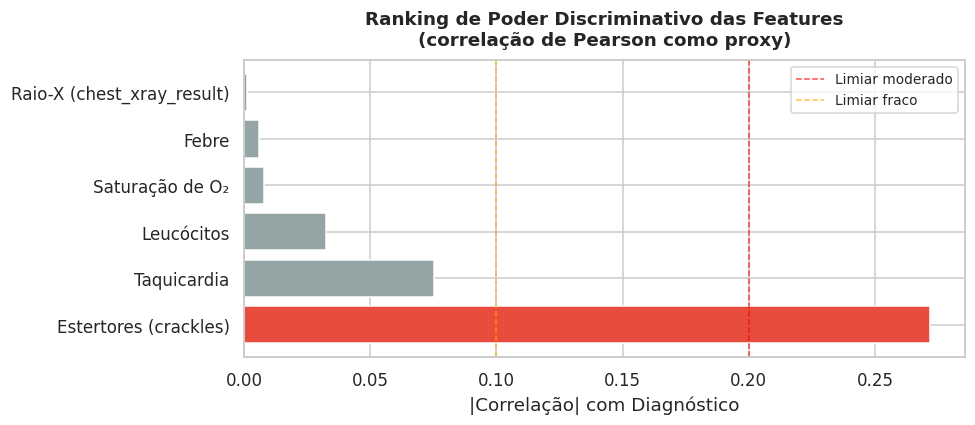

Gráfico salvo em reports/eda_ranking_features.png


In [15]:
# Correlação absoluta com o target (como proxy de importância)
corr_com_target = df_corr.corr()['diagnostico_enc'].drop('diagnostico_enc').abs().sort_values(ascending=False)

nomes_display = {
    'crackles'         : 'Estertores (crackles)',
    'tachycardia'      : 'Taquicardia',
    'wbc_count'        : 'Leucócitos',
    'chest_xray_enc'   : 'Raio-X (chest_xray_result)',
    'fever'            : 'Febre',
    'oxygen_saturation': 'Saturação de O₂',
}

ranking = pd.DataFrame({
    'Feature'   : [nomes_display.get(i, i) for i in corr_com_target.index],
    '|Corr|'    : corr_com_target.values,
    'Poder'     : ['★★★' if v > 0.2 else '★★' if v > 0.1 else '★' for v in corr_com_target.values]
})

display(ranking)

plt.figure(figsize=(9, 4))
cores_barras = ['#E74C3C' if v > 0.2 else '#F39C12' if v > 0.1 else '#95A5A6' for v in corr_com_target.values]
plt.barh(range(len(corr_com_target)), corr_com_target.values, color=cores_barras, edgecolor='white')
plt.yticks(range(len(corr_com_target)), [nomes_display.get(i, i) for i in corr_com_target.index])
plt.xlabel('|Correlação| com Diagnóstico')
plt.title('Ranking de Poder Discriminativo das Features\n(correlação de Pearson como proxy)',
          fontweight='bold', pad=10)
plt.axvline(0.2, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Limiar moderado')
plt.axvline(0.1, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Limiar fraco')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{REPORTS_PATH}eda_ranking_features.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico salvo em reports/eda_ranking_features.png')

**Ranking de importância (baseado em correlação linear com o target):**

1. **Estertores (crackles)** ★★★ — único preditor com correlação moderada. Sinal clínico clássico de pneumonia.
2. **Taquicardia** ★★ — correlação fraca. Ligeiramente mais frequente na atelectasia.
3. **Demais features** ★ — correlação muito fraca. Contribuição marginal de forma isolada.

> **Nota:** Correlação linear é apenas um proxy. Modelos de ensemble (Random Forest) capturam relações não-lineares e interações entre features — podem encontrar padrões que a correlação não detecta. O SHAP na etapa 2.7 dará a visão definitiva da importância real de cada feature.

---

## 14. Conclusões da EDA

### Resumo dos achados

| Aspecto | Resultado | Impacto no projeto |
|---|---|---|
| **Balanceamento** | Perfeitamente balanceado (33,3% por classe) | Não precisa de SMOTE ou class_weight |
| **Valores nulos** | Zero nulos | Sem necessidade de imputação |
| **Outliers** | Dentro de faixas clínicas plausíveis | Nenhum será removido |
| **Multicolinearidade** | Máxima correlação entre features: <0.15 | Todas as 6 features mantidas |
| **Feature mais discriminativa** | `crackles` (correlação -0.27 com target) | Esperar alta importância no SHAP |
| **Feature categórica** | `chest_xray_result` sem poder discriminativo | Encoding necessário, contribuição limitada |
| **Features numéricas** | `oxygen_saturation` e `wbc_count` idênticas entre classes | Baixa contribuição esperada individualmente |

### Decisões confirmadas para o Pré-processamento (Etapa 2.3)

1. **Descartar:** `patient_id`, `timestamp`, `note_sequence`, `clinical_note`, `uncertainty_score`
2. **Manter como features:** `fever`, `tachycardia`, `crackles`, `oxygen_saturation`, `wbc_count`, `chest_xray_result`
3. **Encoding:** `chest_xray_result` → One-Hot Encoding (5 categorias nominais, sem ordem)
4. **Normalização:** `StandardScaler` em `oxygen_saturation` e `wbc_count` (modelos sensíveis a escala: KNN, Regressão Logística)
5. **Split por `patient_id`:** evitar leakage temporal entre as 5 notas do mesmo paciente
6. **Outliers:** sem remoção — valores clinicamente válidos
7. **Imputação:** desnecessária — zero nulos

### Hipótese sobre desempenho dos modelos

Dado que as features têm **baixo poder discriminativo linear**, espera-se que:
- **Modelos de ensemble** (Random Forest) superem modelos lineares (Regressão Logística)
- A **Accuracy global** fique acima de 33% (baseline aleatório) mas provavelmente abaixo de 70%
- `crackles` e possivelmente interações entre features serão determinantes para as predições
- **Recall por classe** será a métrica-chave para avaliar se o modelo identifica corretamente cada condição

---

## Próximo passo

**`03_preprocessamento.ipynb`** — Etapa 2.3: Pré-processamento e preparação dos dados para o treinamento:
- Remover colunas descartadas
- Aplicar One-Hot Encoding em `chest_xray_result`
- Realizar split por `patient_id` (treino/validação/teste)
- Aplicar `StandardScaler` com fit apenas no treino
- Salvar splits e scaler para as etapas seguintes